In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("../")

In [3]:
import glob
import joblib
import pandas as pd
#from pathlib import Path
import matplotlib.pyplot as plt

from phonetics import utils as u
from phonetics import phone_info as ph_i 
from phonetics import plots as plots

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [4]:
root = '/Users/tomasandrade/Documents/BSC/ICHOIR/applio/Applio_LS/experiments'
experiment_path = f'{root}/maria_v2_NEW/feat_768d'
feat_path = f'{experiment_path}/feat_768d_layer_12.csv'

In [5]:
df_anotated = pd.read_csv(feat_path, index_col=0)

phoneme_order = list(df_anotated['phone_base'].value_counts().keys())
rank = {p: i for i, p in enumerate(phoneme_order)}

df_anotated = (
    df_anotated
    .assign(_phoneme_rank=df_anotated["phone_base"].map(rank))
    .sort_values(
        ["_phoneme_rank", "duration"],
        kind="mergesort"
    )
    .drop(columns="_phoneme_rank")
    .reset_index(drop=True)
)

<Axes: xlabel='phone_base'>

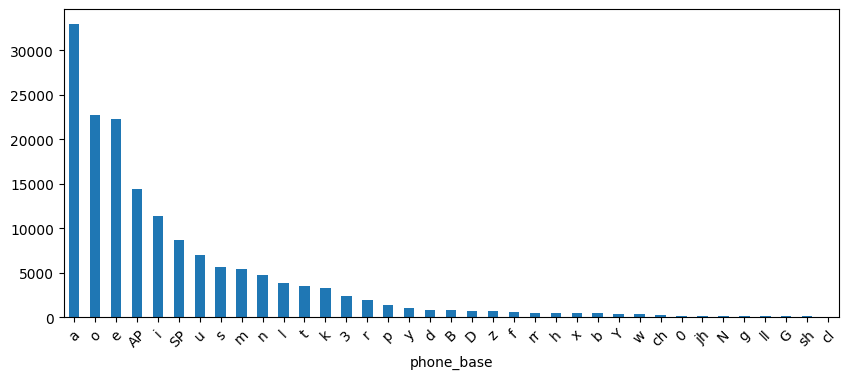

In [6]:
plt.figure(figsize=(10,4))
df_anotated['phone_base'].value_counts().plot.bar(rot = 45)

In [7]:
len(df_anotated['phone_base'])*0.02/60

53.20033333333333

In [8]:
df_anotated['song'].unique()

array(['ES_el_dia_que_naci_yo', 'ES_tu_que_vienes_a_rondarme',
       'CA_la_pastoreta', 'ES_milagro', 'ES_ventura2',
       'ES_lucero_de_la_maniana', 'ES_hildegart', 'CA_meteorit_ferit',
       'ES_quien_me_ama', 'CA_mabravasa', 'ES_volver_a_los_17',
       'CA_viola', 'ES_ventura', 'CA_impro', 'ES_negro_infinito',
       'CA_no_he_desitjat', 'CA_sol_solet', 'ES_jota', 'ES_galapaguito',
       'CA_impro2', 'ES_que_lejos_estoy_de_la_tierra', 'CA_xiqueta_meuna',
       'CA_impro3', 'ES_tras_de_ti', 'CA_sibi_la',
       'ES_la_sobra_de_la_luz', 'CA_un_gat_petit_tv3', 'CA_sol_solet-2',
       'ES_yo_vi_secarse_una_jara', 'CA_tu_saps'], dtype=object)

In [9]:
umap2 = u.train_umap(
        df_anotated,
        exclude_phones = ['SP'],
        n_components=2, 
        n_neighbors=100, 
        min_dist=0.1,
        n_jobs = 1,
        save_model = False,
        folder = None)

df_proj2d = u.make_proj_anotated_feat_df(df_anotated, 
                                        umap2,
                                        save_df = False,
                                        folder = None)

Training UMAP with parameters n_components : 2, n_neighbors 100, min_dist : 0.1, n_jobs : 1
Finished umap traning. Training time: 335.5477948188782
Applying dimensional reduction
Reduced to 2 dimensions
Finished computing projection. Transform time :91.08361506462097


In [10]:
unique_phones = [k for k in df_proj2d['phone_base'].value_counts().keys() if k != 'SP']

Making a 2d plot


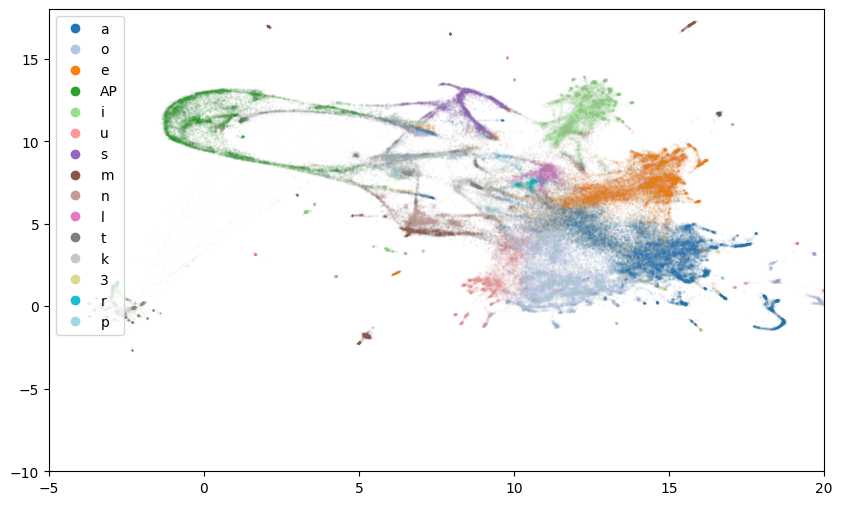

In [11]:
plots.make_tagged_LS_plot(df_proj2d,
            phones = unique_phones[:15],
            alpha = 0.1, 
            s = 0.1,
            show_global=True,
            xlim = [ -5, 20],
            ylim = [-10, 18])

In [12]:
umap3 = u.train_umap(
        df_anotated,
        exclude_phones = ['SP'],
        n_components=3, 
        n_neighbors=100, 
        min_dist=0.1,
        n_jobs = 1,
        save_model = False,
        folder = None)

Training UMAP with parameters n_components : 3, n_neighbors 100, min_dist : 0.1, n_jobs : 1
Finished umap traning. Training time: 332.0538578033447


In [25]:
df_proj3d = u.make_proj_anotated_feat_df(df_anotated_all, 
                                        umap3,
                                        save_df = False,
                                        folder = None)

Applying dimensional reduction
Reduced to 3 dimensions
Finished computing projection. Transform time :168.92993712425232


Making a 3d plot


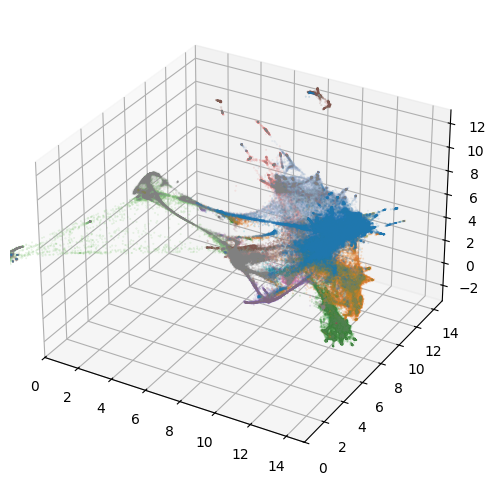

In [23]:
plots.make_tagged_LS_plot(df_proj3d,
            phones = unique_phones[:15],
            alpha = 0.25, 
            s = 0.1,
            show_global=True, 
            add_legend=False,
            xlim=[0,15],
            ylim=[0,15])

# edna MN comparison

In [36]:
import pandas as pd
#from pathlib import Path
import matplotlib.pyplot as plt

from phonetics import plots as plots

In [24]:
root = '/Users/tomasandrade/Documents/BSC/ICHOIR/datasets/pellizco_25122025/global_ls/umap_projections'
edna_file_2d = f'{root}/edna_result/df_proj_anotated_nn_100_min_dist_0.1_2d.csv'
edna_file_3d = f'{root}/edna_result/df_proj_anotated_nn_100_min_dist_0.3_3d.csv'

mn_file_2d = f'{root}/mn_result/df_proj_anotated_test_2d.csv'
mn_file_3d = f'{root}/mn_result/df_proj_anotated_test_3d.csv'

In [25]:
df_edna_2d = pd.read_csv(edna_file_2d, index_col=0)
df_mn_2d = pd.read_csv(mn_file_2d, index_col=0)

df_edna_3d = pd.read_csv(edna_file_3d, index_col=0)
df_mn_3d = pd.read_csv(mn_file_3d, index_col=0)

In [26]:
unique_phones = [k for k in df_mn_2d['phone_base'].value_counts().keys() if k != 'AP']

Making a 2d plot


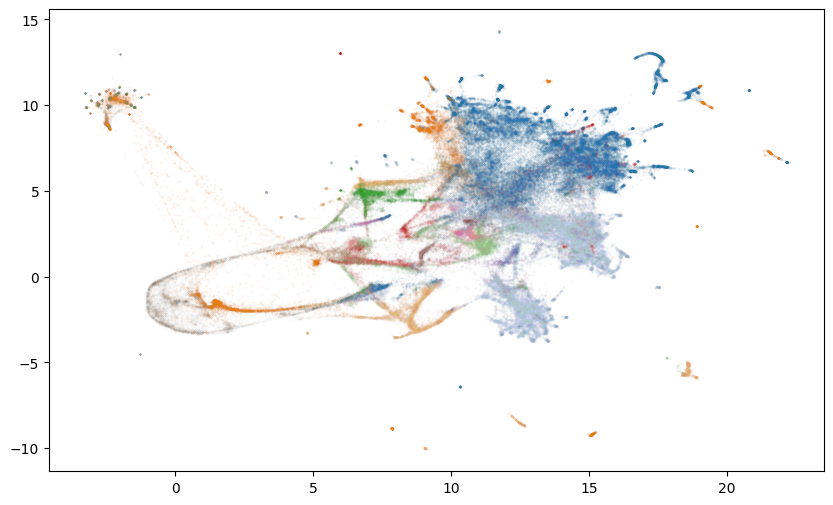

In [27]:
plots.make_tagged_LS_plot(df_edna_2d,
            phones = unique_phones,
            alpha = 0.1, 
            s = 0.1,
            show_global=True,
            add_legend=False)

Making a 2d plot


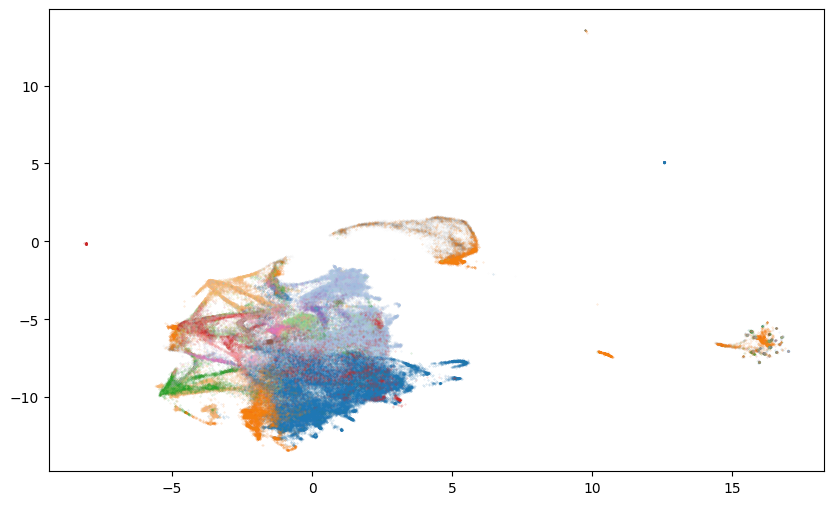

In [28]:
plots.make_tagged_LS_plot(df_mn_2d,
            phones = unique_phones,
            alpha = 0.25, 
            s = 0.1,
            show_global=True,
            add_legend=False)

Making a 3d plot


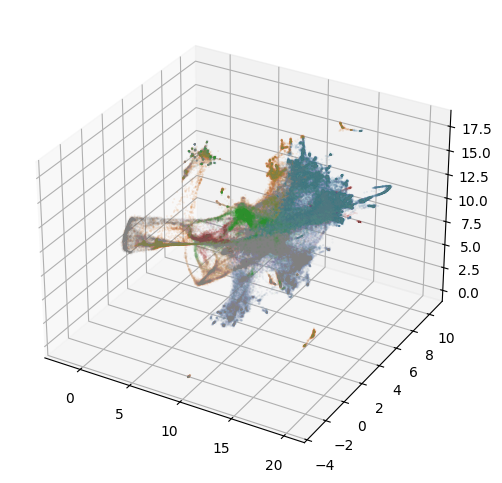

In [29]:
plots.make_tagged_LS_plot(df_edna_3d,
            phones = unique_phones,
            alpha = 0.1, 
            s = 0.1,
            show_global=True,
            add_legend=False)

Making a 3d plot


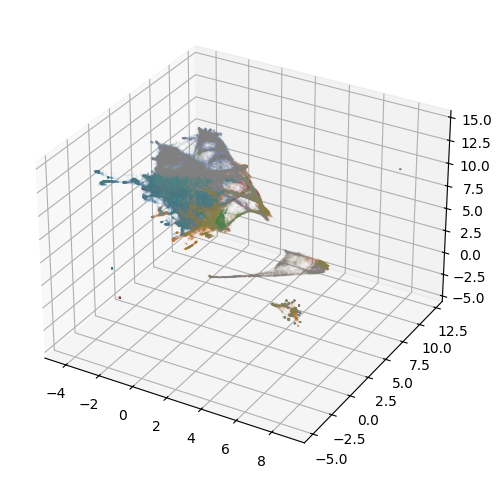

In [30]:
plots.make_tagged_LS_plot(df_mn_3d,
            phones = unique_phones,
            alpha = 0.1, 
            s = 0.1,
            show_global=True,
            add_legend=False)

# 3d scan

In [4]:
import glob

In [31]:
root = '/Users/tomasandrade/Documents/BSC/ICHOIR/datasets/pellizco_25122025/global_ls/umap_projections/'

In [32]:
all_files = sorted(glob.glob(f'{root}/edna_result/*'))
all_files

['/Users/tomasandrade/Documents/BSC/ICHOIR/datasets/pellizco_25122025/global_ls/umap_projections//edna_result/df_proj_anotated_nn_100_min_dist_0.1_2d.csv',
 '/Users/tomasandrade/Documents/BSC/ICHOIR/datasets/pellizco_25122025/global_ls/umap_projections//edna_result/df_proj_anotated_nn_100_min_dist_0.1_3d.csv',
 '/Users/tomasandrade/Documents/BSC/ICHOIR/datasets/pellizco_25122025/global_ls/umap_projections//edna_result/df_proj_anotated_nn_100_min_dist_0.2_3d.csv',
 '/Users/tomasandrade/Documents/BSC/ICHOIR/datasets/pellizco_25122025/global_ls/umap_projections//edna_result/df_proj_anotated_nn_100_min_dist_0.3_3d.csv']

Making a 2d plot
Making a 3d plot
Making a 3d plot
Making a 3d plot


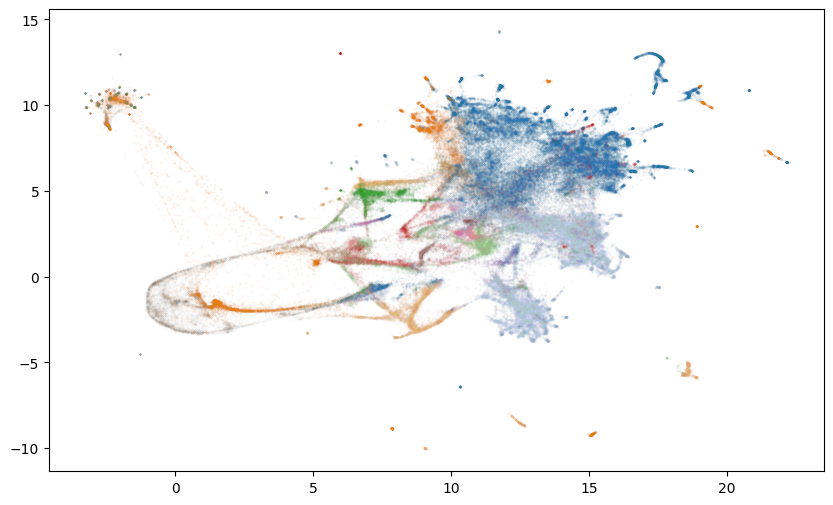

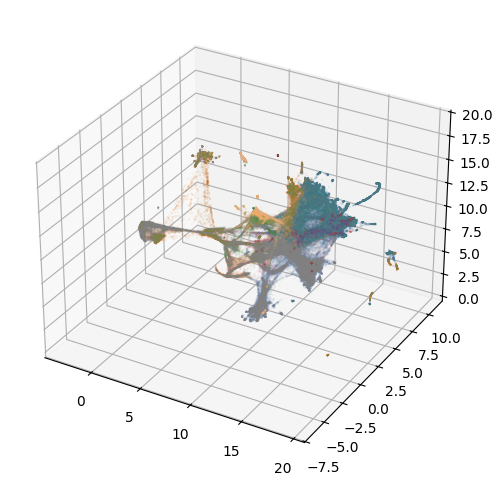

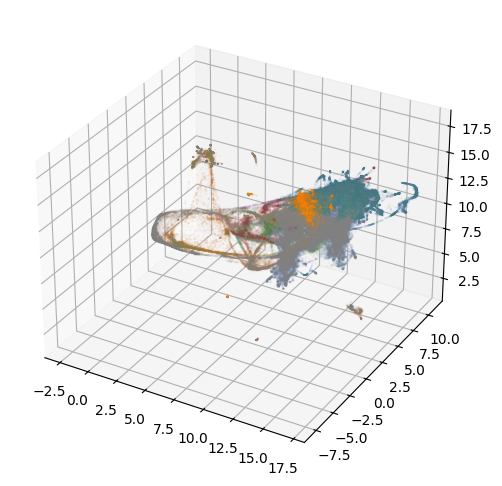

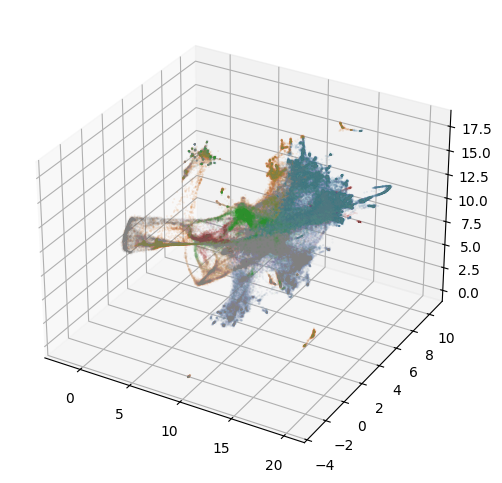

In [33]:
for f in all_files:
    df_edna_3d = pd.read_csv(f, index_col=0)
    plots.make_tagged_LS_plot(df_edna_3d,
            phones = unique_phones,
            alpha = 0.1, 
            s = 0.1,
            show_global=True,
            add_legend=False)

Making a 2d plot


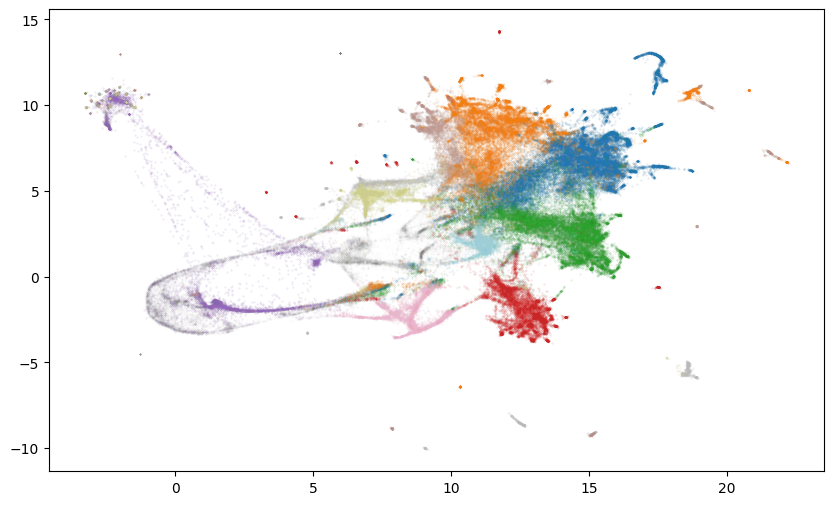

In [35]:
file = f'{root}/edna_result/df_proj_anotated_nn_100_min_dist_0.1_2d.csv'
df_edna_2d = pd.read_csv(file, index_col=0)

unique_phones = [k for k in df_edna_2d['phone_base'].value_counts().keys() if k != 'AP']

plots.make_tagged_LS_plot(df_edna_2d,
            phones = unique_phones[0:10],
            alpha = 0.2, 
            s = 0.1,
            show_global=True,
            add_legend=False)

Making a 3d plot


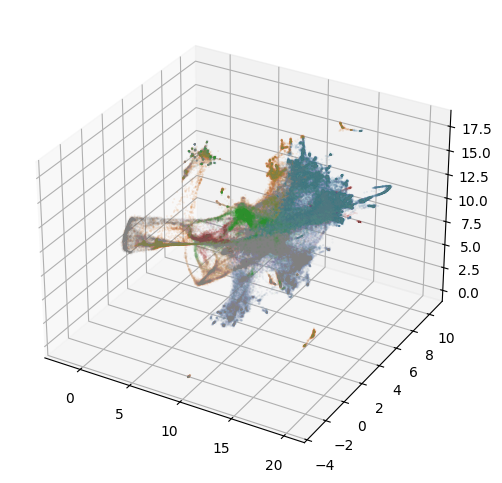

In [40]:
#file = '/Users/tomasandrade/Desktop/edna_result/umap_test/'
file = f'{root}/edna_result/df_proj_anotated_nn_100_min_dist_0.3_3d.csv'
df_edna_3d = pd.read_csv(file, index_col=0)
plots.make_tagged_LS_plot(df_edna_3d,
        phones = unique_phones,
        alpha = 0.1, 
        s = 0.1,
        show_global=True,
        add_legend=False)

# Edna experiment version

In [7]:
root = '/Users/tomasandrade/Documents/BSC/ICHOIR/datasets/pellizco_25122025/experiments'

Making a 2d plot


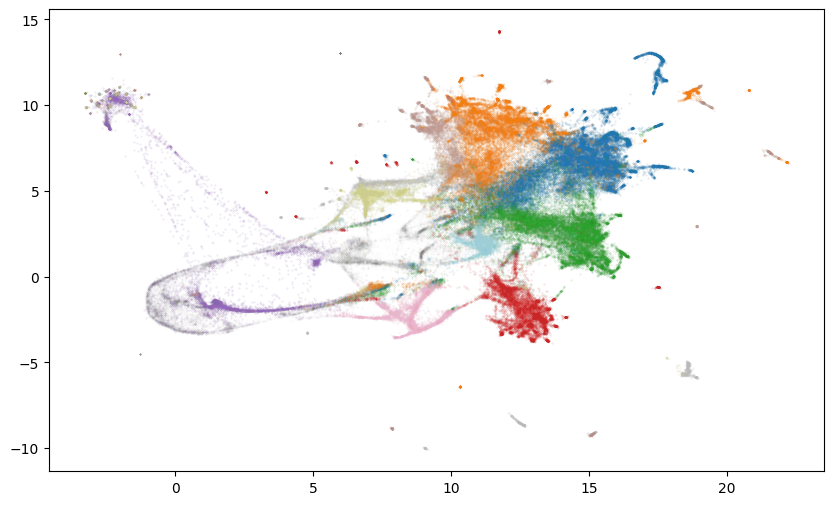

In [8]:
file = f'{root}/maria_2d/feat_2d/feat_2d_layer_12.csv'
df_2d = pd.read_csv(file, index_col=0)

unique_phones = [k for k in df_2d['phone_base'].value_counts().keys() if k != 'AP']

plots.make_tagged_LS_plot(df_2d,
            phones = unique_phones[0:10],
            alpha = 0.2, 
            s = 0.1,
            show_global=True,
            add_legend=False)

In [5]:
file_3d = f'{root}/maria_3d/feat_3d/feat_3d_layer_12.csv'
df_3d = pd.read_csv(file_3d, index_col=0)

Making a 3d plot


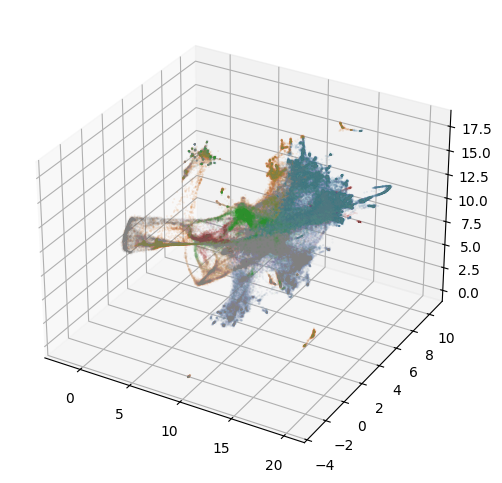

In [6]:
unique_phones = [k for k in df_3d['phone_base'].value_counts().keys() if k != 'AP']

plots.make_tagged_LS_plot(df_3d,
            phones = unique_phones,
            alpha = 0.1, 
            s = 0.1,
            show_global=True,
            add_legend=False)